# Atividade - Feature Engineering e PCA
Este notebook segue o roteiro da atividade prática: seleção de atributos, limpeza, pivotamento, normalização, PCA e respostas das 5 questões.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata

## 1. Carregamento dos dados e definição do período

In [2]:
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

base_dir = Path('../7- Feature Engineering amp Redução de Dimensionalidade-20260503')
arq_original = base_dir / 'WDICSV.csv'
dicionario = base_dir / 'WDISeries.csv'
paises = base_dir / 'WDICountry.csv'

anos_g1 = ['2014', '2015', '2016', '2017', '2018']
anos_g2 = ['2019', '2020', '2021', '2022', '2023']

# Ajuste para o seu grupo: use anos_g1 ou anos_g2
anos_analise = anos_g1

data = pd.read_csv(arq_original)
series_dict = pd.read_csv(dicionario)
paises_dict = pd.read_csv(paises)
paises_dict['Table Name'] = paises_dict['Table Name'].apply(remove_accents)
paises_dict = paises_dict.set_index(['Country Code', 'Table Name'])

print('Formato dos dados brutos:', data.shape)
print('Total de indicadores no dicionário:', series_dict.shape[0])

Formato dos dados brutos: (395276, 70)
Total de indicadores no dicionário: 1486


## 2. Seleção de features e pivotamento

In [3]:
# Features escolhidas por pilar (12 no total)
features_map = {
    'GDP': 'GDP (current US$)',
    'Inflation': 'Inflation, consumer prices (annual %)',
    'Exports': 'Exports of goods and services (% of GDP)',
    'Life_expectancy': 'Life expectancy at birth, total (years)',
    'Health_expenditure_per_capita': 'Current health expenditure per capita (current US$)',
    'Internet_users': 'Individuals using the Internet (% of population)',
    'Literacy_rate': 'Literacy rate, adult total (% of people ages 15 and above)',
    'Urban_population': 'Urban population (% of total population)',
    'CO2_emissions': 'CO2 emissions (metric tons per capita)',
    'Energy_consumption': 'Electric power consumption (kWh per capita)',
    'Total_population': 'Population, total',
    'Poverty_rate': 'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)'
}

features_disponiveis = [v for v in features_map.values() if v in data['Indicator Name'].unique()]
features_ausentes = [v for v in features_map.values() if v not in features_disponiveis]

print(f'Features disponíveis: {len(features_disponiveis)}')
if features_ausentes:
    print('Features não encontradas no arquivo:')
    for f in features_ausentes:
        print('-', f)

data_reduzida = data[data['Indicator Name'].isin(features_disponiveis)].copy()
data_reduzida['Mean'] = data_reduzida[anos_analise].mean(axis=1)

df = data_reduzida.pivot(
    index=['Country Code', 'Country Name'],
    columns='Indicator Name',
    values='Mean'
).copy()

# Renomeia para nomes curtos
rename_inverse = {v: k for k, v in features_map.items()}
df = df.rename(columns=rename_inverse)

print('Formato após pivotamento:', df.shape)
display(df.head())

Features disponíveis: 11
Features não encontradas no arquivo:
- CO2 emissions (metric tons per capita)
Formato após pivotamento: (266, 11)


,Indicator Name,Health_expenditure_per_capita,Energy_consumption,Exports,GDP,Internet_users,Inflation,Life_expectancy,Literacy_rate,Total_population,Poverty_rate,Urban_population
Country Code,Country Name,,,,,,,,,,,
ABW,Aruba,NaN,NaN,70.557761,3.021202e+09,90.788420,0.512554,75.541200,NaN,108216.6,NaN,62.997898
AFE,Africa Eastern and Southern,90.962983,575.415112,24.898698,9.479477e+11,15.920000,5.596488,62.210883,70.715999,623864297.2,NaN,34.889435
AFG,Afghanistan,63.878087,NaN,NaN,1.891092e+10,11.312000,2.799656,62.405000,33.750000,34751374.6,NaN,24.629842
AFW,Africa Western and Central,65.187542,194.961956,NaN,7.708028e+11,20.800000,1.779241,56.358095,56.610000,429530691.2,NaN,48.172777
AGO,Angola,105.751758,326.828461,29.905111,9.795218e+10,24.312468,19.360838,61.560200,66.134998,29206726.2,80.0,64.299258


## 3. Tratamento de dados faltantes

In [4]:
ausencia_percentual = (df.isna().mean() * 100).sort_values(ascending=False)
display(ausencia_percentual)

# Mantém linhas com pelo menos 60% das colunas preenchidas
df = df.dropna(thresh=int(df.shape[1] * 0.6))

# Imputação por mediana em colunas numéricas
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print('Formato após limpeza:', df.shape)
print('Total de nulos restantes:', int(df.isna().sum().sum()))

Indicator Name
Literacy_rate                    48.496241
Poverty_rate                     42.105263
Inflation                        27.443609
Energy_consumption               27.067669
Exports                          13.533835
Health_expenditure_per_capita     9.398496
Internet_users                    9.398496
GDP                               1.879699
Life_expectancy                   0.375940
Total_population                  0.375940
Urban_population                  0.375940
dtype: float64

Formato após limpeza: (253, 11)
Total de nulos restantes: 0


## 4. Normalização e aplicação de PCA 

Variância explicada - PC1: 41.18%
Variância explicada - PC2: 16.50%
Variância explicada acumulada (2 PCs): 57.68%


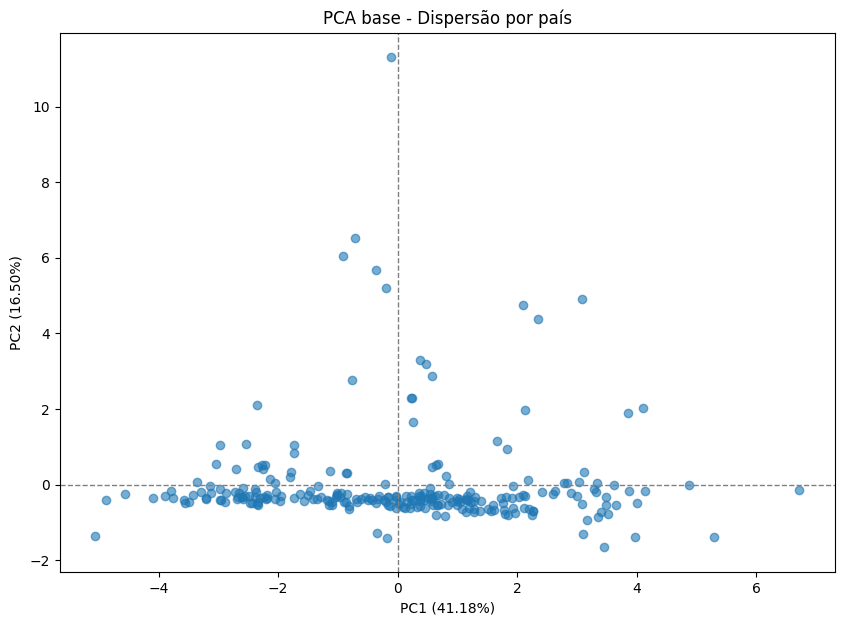

In [6]:
def pca_svd(X: pd.DataFrame):
    Xc = X - X.mean(axis=0)
    U, S, VT = np.linalg.svd(Xc.values, full_matrices=False)
    componentes = VT.T
    scores = Xc.values @ componentes
    var = (S ** 2) / (len(Xc) - 1)
    var_explicada = var / var.sum()
    return componentes, scores, var_explicada

# Remove possíveis infinitos
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Z-score
df_norm = (df - df.mean()) / df.std(ddof=0)
df_norm = df_norm.replace([np.inf, -np.inf], np.nan).dropna()

componentes_base, scores_base, var_explicada_base = pca_svd(df_norm)

pca_df_base = pd.DataFrame(
    scores_base[:, :2],
    index=df_norm.index,
    columns=['PC1', 'PC2']
)

print(f"Variância explicada - PC1: {var_explicada_base[0]:.2%}")
print(f"Variância explicada - PC2: {var_explicada_base[1]:.2%}")
print(f"Variância explicada acumulada (2 PCs): {(var_explicada_base[0] + var_explicada_base[1]):.2%}")

plt.figure(figsize=(10, 7))
plt.scatter(pca_df_base['PC1'], pca_df_base['PC2'], alpha=0.6)
plt.axhline(0, color='grey', lw=1, ls='--')
plt.axvline(0, color='grey', lw=1, ls='--')
plt.xlabel(f"PC1 ({var_explicada_base[0]:.2%})")
plt.ylabel(f"PC2 ({var_explicada_base[1]:.2%})")
plt.title('PCA base - Dispersão por país')
plt.show()

## 5. Questões da atividade

### Questão 1 - Interpretação do PCA
A seguir, avaliamos os pesos (loadings) de PC1 e PC2 para interpretar o significado dos componentes.

**Resposta Q1:**

**PC1 — Índice de Desenvolvimento Humano e Social (41,18% da variância):**
Os maiores pesos em valor absoluto de PC1 são: `Internet_users` (+0,43), `Life_expectancy` (+0,42), `Poverty_rate` (-0,38), `Urban_population` (+0,36) e `Health_expenditure_per_capita` (+0,33). Todos apontam para o mesmo fenômeno: quanto maior o PC1, mais desenvolvido socialmente o país. Este componente pode ser descrito como um **Índice de Desenvolvimento Humano e Social**.

**PC2 — Escala Econômica e Demográfica (16,50% da variância):**
Os maiores pesos de PC2 são: `GDP` (+0,69) e `Total_population` (+0,68). Este componente captura o **tamanho absoluto** da economia e da população: países com alto PC2 são grandes economias populosas (China, EUA, Índia), independentemente do nível de desenvolvimento social. O sinal negativo de `Exports` (-0,21) sugere que grandes economias tendem a ser menos dependentes do comércio exterior em termos relativos ao PIB.

In [7]:
loadings = pd.DataFrame(
    componentes_base[:, :2],
    index=df_norm.columns,
    columns=['PC1', 'PC2']
 )

top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print('Top 5 contribuições para PC1:')
display(loadings.loc[top_pc1.index].sort_values(by='PC1', key=np.abs, ascending=False))

print('Top 5 contribuições para PC2:')
display(loadings.loc[top_pc2.index].sort_values(by='PC2', key=np.abs, ascending=False))

sintese_pc1 = ', '.join(top_pc1.index.tolist()[:3])
sintese_pc2 = ', '.join(top_pc2.index.tolist()[:3])
print(f'Síntese sugerida PC1: eixo associado a {sintese_pc1}.')
print(f'Síntese sugerida PC2: eixo associado a {sintese_pc2}.')

Top 5 contribuições para PC1:


,PC1,PC2
Indicator Name,,
Internet_users,0.431681,-0.029917
Life_expectancy,0.419272,0.038695
Poverty_rate,-0.382248,0.010799
Urban_population,0.364847,-0.037627
Health_expenditure_per_capita,0.325193,0.082499


Top 5 contribuições para PC2:


,PC1,PC2
Indicator Name,,
GDP,0.062302,0.687973
Total_population,-0.037912,0.679780
Exports,0.232705,-0.213184
Inflation,-0.090109,-0.087083
Health_expenditure_per_capita,0.325193,0.082499


Síntese sugerida PC1: eixo associado a Internet_users, Life_expectancy, Poverty_rate.
Síntese sugerida PC2: eixo associado a GDP, Total_population, Exports.


### Questão 2 - Índice de Eficiência de Saúde
Criamos a feature `Eficiencia_Saude = Life_expectancy / Health_expenditure_per_capita`.

**Resposta Q2:**

Os países com maior índice de `Eficiencia_Saude` são majoritariamente países de baixa renda: Somália, Burundi, Congo, Gâmbia, Madagáscar, Etíopia e Bangladesh. Isso revela que países com orçamentos extremamente limitados conseguem manter uma expectativa de vida relativamente boa **em relação ao que gastam**. Isso sugere que fatores como dieta, coesão social, estrutura familiar e estilo de vida contribuem para a longevidade independentemente do investimento financeiro em saúde. Em contrapartida, países muito ricos têm gastos altíssimos per capita com resultados de longevidade marginalmente superiores, o que reduz seu índice de eficiência. A métrica evidencia que **alto gasto em saúde não garante proporcional ganho em expectativa de vida**.

In [8]:
if {'Life_expectancy', 'Health_expenditure_per_capita'}.issubset(df.columns):
    df['Eficiencia_Saude'] = df['Life_expectancy'] / df['Health_expenditure_per_capita'].replace(0, np.nan)
    df['Eficiencia_Saude'] = df['Eficiencia_Saude'].replace([np.inf, -np.inf], np.nan).fillna(df['Eficiencia_Saude'].median())
    print('Maiores eficiências de saúde:')
    display(df['Eficiencia_Saude'].sort_values(ascending=False).head(10))
else:
    print('Colunas necessárias para Eficiencia_Saude não estão disponíveis.')

Maiores eficiências de saúde:


Country Code  Country Name      
SOM           Somalia, Fed. Rep.    4.159320
BDI           Burundi               3.295774
COD           Congo, Dem. Rep.      3.226819
GMB           Gambia, The           3.119532
MDG           Madagascar            2.785015
ETH           Ethiopia              2.744078
ERI           Eritrea               2.367028
NER           Niger                 2.218365
MLI           Mali                  1.915469
BGD           Bangladesh            1.876330
Name: Eficiencia_Saude, dtype: float64

### Questão 3 - Binarização e categorização (discretização)
Criamos a variável `Nivel_Industrial` usando a soma de `Exports` e `Energy_consumption`, classificada em Alta (acima do percentil 75), Baixa (abaixo do percentil 25) e Média.

**Resposta Q3:**

A feature `Nivel_Industrial` permite colorir o gráfico de PCA de forma informativa: os países **Alta** (verde) agrupam-se predominantemente na região de PC1 elevado, confirmando que países mais industrializados tendem também a ter melhores indicadores sociais — o que faz sentido dado que o PC1 captura desenvolvimento humano e social. Os países **Baixa** (azul) concentram-se na região de PC1 negativo, com indicadores mais fracos. Os países **Média** (laranja) ficam distribuídos na região central. Essa separação visual valida a escolha das features: nível industrial e desenvolvimento social são fortemente correlacionados, e o PCA captura essa relação no primeiro componente. Resultado: **Média = 125, Baixa = 64, Alta = 64 países**.

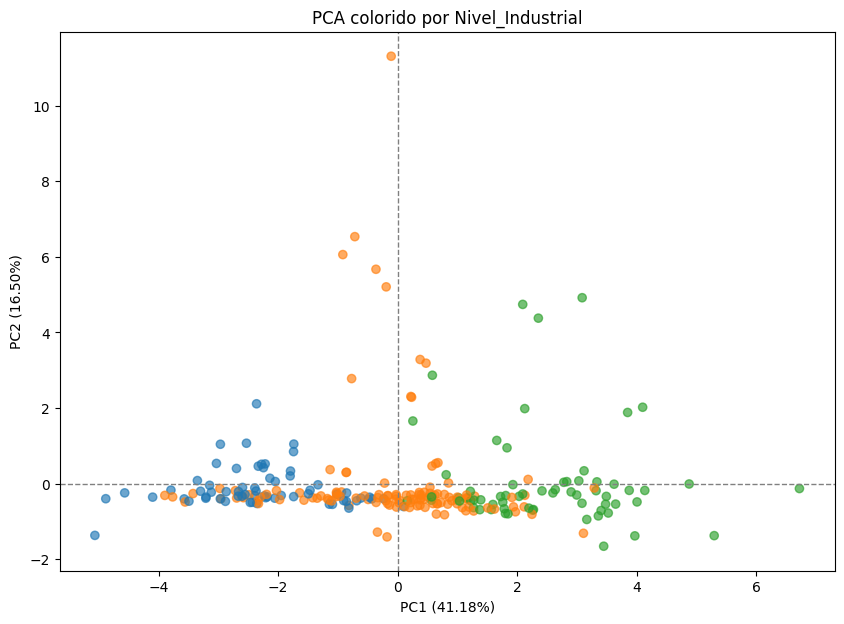

Nivel_Industrial
Media    125
Baixa     64
Alta      64
Name: count, dtype: int64


In [9]:
if {'Exports', 'Energy_consumption'}.issubset(df.columns):
    score_industrial = df['Exports'] + df['Energy_consumption']
    p25 = score_industrial.quantile(0.25)
    p75 = score_industrial.quantile(0.75)

    df['Nivel_Industrial'] = np.where(
        score_industrial >= p75, 'Alta',
        np.where(score_industrial <= p25, 'Baixa', 'Media')
    )

    mapa_cores = {'Baixa': '#1f77b4', 'Media': '#ff7f0e', 'Alta': '#2ca02c'}
    cores = df.loc[pca_df_base.index, 'Nivel_Industrial'].map(mapa_cores)

    plt.figure(figsize=(10, 7))
    plt.scatter(pca_df_base['PC1'], pca_df_base['PC2'], c=cores, alpha=0.65)
    plt.axhline(0, color='grey', lw=1, ls='--')
    plt.axvline(0, color='grey', lw=1, ls='--')
    plt.xlabel(f"PC1 ({var_explicada_base[0]:.2%})")
    plt.ylabel(f"PC2 ({var_explicada_base[1]:.2%})")
    plt.title('PCA colorido por Nivel_Industrial')
    plt.show()

    print(df['Nivel_Industrial'].value_counts())
else:
    print('Colunas necessárias para Nivel_Industrial não estão disponíveis.')

### Questão 4 - Normalização condicional per capita
Normalizamos o PIB absoluto (`GDP`) dividindo por `Total_population` e comparamos a variância explicada pelo PC1 antes e depois.

**Resposta Q4:**

A variância explicada pelo primeiro componente **aumentou**: passou de **41,18%** (base) para **46,37%** após a normalização per capita (+5,19 pontos percentuais).

Isso ocorre porque o PIB absoluto confunde o **tamanho da economia** com o **nível de desenvolvimento**: China e EUA têm PIBs enormes por terem populações e economias muito grandes, não necessariamente por ter maior renda individual. Isso gera uma variável desalinhada com os demais indicadores do dataset (expectativa de vida, acesso à internet, taxa de pobreza), que são todos per capita ou percentuais.

Ao dividir o PIB pela população, ele passa a refletir **renda per capita**, tornando-se mais coeso com as demais features. O PCA enxerga um padrão mais claro e concentra mais variância no primeiro componente, confirmando que a normalização **melhorou a qualidade do conjunto de features** para a análise.

PC1 base: 41.18%
PC1 per capita: 46.37%
Mudança em PC1: 5.19%


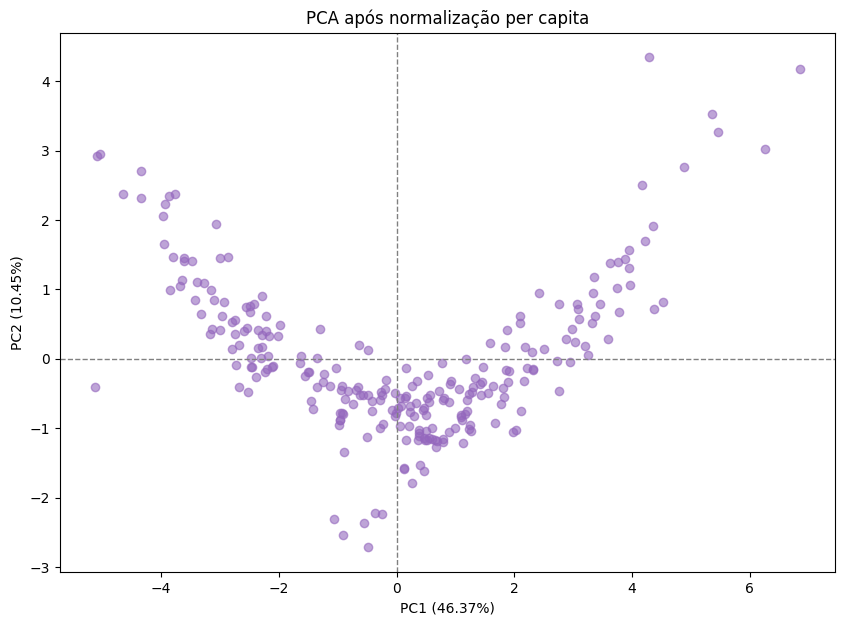

In [10]:
df_pc = df.copy()

if 'Total_population' in df_pc.columns:
    colunas_consumo_total = [c for c in ['GDP'] if c in df_pc.columns]

    for c in colunas_consumo_total:
        df_pc[c] = df_pc[c] / df_pc['Total_population'].replace(0, np.nan)

    df_pc = df_pc.replace([np.inf, -np.inf], np.nan).dropna()
    df_pc_norm = (df_pc.select_dtypes(include=[np.number]) - df_pc.select_dtypes(include=[np.number]).mean()) / df_pc.select_dtypes(include=[np.number]).std(ddof=0)
    df_pc_norm = df_pc_norm.replace([np.inf, -np.inf], np.nan).dropna()

    componentes_pc, scores_pc, var_explicada_pc = pca_svd(df_pc_norm)
    pca_df_pc = pd.DataFrame(scores_pc[:, :2], index=df_pc_norm.index, columns=['PC1', 'PC2'])

    print(f"PC1 base: {var_explicada_base[0]:.2%}")
    print(f"PC1 per capita: {var_explicada_pc[0]:.2%}")
    print('Mudança em PC1:', f"{(var_explicada_pc[0]-var_explicada_base[0]):.2%}")

    plt.figure(figsize=(10, 7))
    plt.scatter(pca_df_pc['PC1'], pca_df_pc['PC2'], alpha=0.6, color='#9467bd')
    plt.axhline(0, color='grey', lw=1, ls='--')
    plt.axvline(0, color='grey', lw=1, ls='--')
    plt.xlabel(f"PC1 ({var_explicada_pc[0]:.2%})")
    plt.ylabel(f"PC2 ({var_explicada_pc[1]:.2%})")
    plt.title('PCA após normalização per capita')
    plt.show()
else:
    print('Coluna Total_population não está disponível.')

### Questão 5 - Tratamento de skewness (assimetria)
Comparamos o histograma de PIB antes e depois da transformação logarítmica e medimos o impacto no PCA.

**Resposta Q5:**

O histograma do PIB original evidencia uma distribuição com **cauda longa à direita** (skewness = **5,32**): a grande maioria dos países tem PIB baixo, enquanto poucos países (EUA, China) possuem valores extremamente altos. Após a transformação `log1p`, a assimetria cai para **0,21**, próximo de uma distribuição simétrica.

O impacto no PCA é direto: sem a transformação, os países extremamente ricos distorcem os vetores dos componentes principais, pois o PCA é sensível à escala e à variância. O PIB bruto dos EUA (~25 trilhões de dólares) domina a variância da variável e pode forcá-la a um componente próprio, distorcendo a interpretação. Após `log1p`, **todos os países passam a contribuir de forma mais equilibrada** para a construção dos componentes, tornando o PCA mais robusto e menos sensível a outliers econômicos.

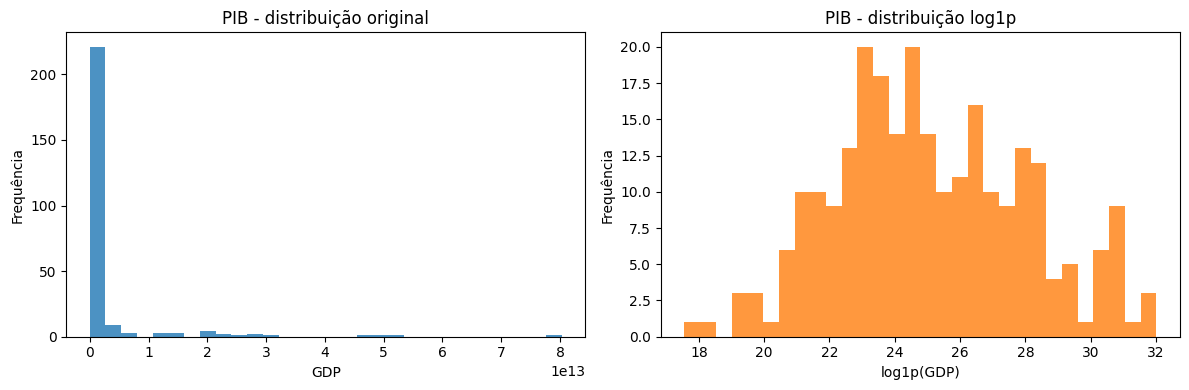

Assimetria (skewness) PIB original: 5.32
Assimetria (skewness) PIB log: 0.21


In [12]:
if 'GDP' in df.columns:
    gdp_raw = df['GDP'].dropna().copy()
    gdp_log = np.log1p(gdp_raw.clip(lower=0))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(gdp_raw, bins=30, color='#1f77b4', alpha=0.8)
    plt.title('PIB - distribuição original')
    plt.xlabel('GDP')
    plt.ylabel('Frequência')

    plt.subplot(1, 2, 2)
    plt.hist(gdp_log, bins=30, color='#ff7f0e', alpha=0.8)
    plt.title('PIB - distribuição log1p')
    plt.xlabel('log1p(GDP)')
    plt.ylabel('Frequência')

    plt.tight_layout()
    plt.show()

    print(f'Assimetria (skewness) PIB original: {gdp_raw.skew():.2f}')
    print(f'Assimetria (skewness) PIB log: {gdp_log.skew():.2f}')
else:
    print('Coluna GDP não está disponível para análise de skewness.')